실패이후, 회전 기준도 잘못잡았지만 회전이 중요한게 아니라 각 베드 사이의 촬영각이 다를테니 이를 기준으로 정규화해야 한다는걸 깨닫고 2번째에서는 지표 추출 및 정규화 기준을 다시 뽑는거로 바꾸었다



*   1캔버스: geometry table + ref 함수 생성 ✅
*   2캔버스: 지표 정규화 적용 ✅
*   3캔버스: 이미지 약한 보정 실험 ✅

이 구조 딱 맞음.



#2번째: 정규화 기준이 될 지표 뽑기

In [1]:
# -*- coding: utf-8 -*-
"""
[STEP 1-2] Geometry table + reference functions 생성
- 입력: per_image_results_v3.csv
- 필터: matched_count==4 (gold subset)
- 산출:
  1) geometry_table.csv (각 행의 theta_obs, W, H 등)
  2) ref_table.csv (x에 따른 theta_ref, W_ref, H_ref)

요구사항 반영
- 대용량 대비: chunk 처리 + 진행률(ETA)
- 병렬: 계산 가벼워서 불필요 → 대신 I/O 안정성 위주

사용 방법
1) CSV_PATH 수정
2) 실행
3) out_dir에 결과 생성
"""

import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm

# ======================
# 경로 설정
# ======================
CSV_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/1. circle_anchor/이름변경 후_to 0412/per_image_results_v4.csv"
OUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412"
os.makedirs(OUT_DIR, exist_ok=True)

# ======================
# 설정
# ======================
CHUNK_SIZE = 2000
USE_ONLY_MATCHED4 = True

# ======================
# 1. geometry 계산 함수
# ======================
def compute_geometry(df):
    # width / height
    W = (df["quad_width_top"] + df["quad_width_bottom"]) / 2.0
    H = (df["quad_height_left"] + df["quad_height_right"]) / 2.0

    # 회전각 (상단/하단 평균)
    theta_obs = (df["top_slope_deg"] + df["bottom_slope_deg"]) / 2.0

    out = pd.DataFrame({
        "image_name": df["image_name"],
        "centroid_x": df["centroid_x"],
        "centroid_y": df["centroid_y"],
        "W": W,
        "H": H,
        "theta_obs": theta_obs,
        "width_ratio": df["width_ratio"],
        "height_ratio": df["height_ratio"] if "height_ratio" in df.columns else np.nan
    })

    return out

# ======================
# 2. LOWESS 근사 (간단 구현)
# ======================
def simple_bin_smooth(x, y, n_bins=20):
    """
    LOWESS 대신 간단한 bin 평균
    x를 구간으로 나눠서 평균값 생성
    """
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    df = df.sort_values("x")

    bins = np.linspace(df["x"].min(), df["x"].max(), n_bins+1)
    df["bin"] = np.digitize(df["x"], bins)

    ref = df.groupby("bin").agg({
        "x": "mean",
        "y": "mean"
    }).dropna()

    return ref["x"].values, ref["y"].values

# ======================
# 3. 메인 처리
# ======================
def main():
    print("[START] geometry table 생성")

    reader = pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE)

    geom_list = []
    total_rows = 0
    t0 = time.time()

    for chunk in tqdm(reader, desc="Processing chunks"):
        if USE_ONLY_MATCHED4:
            chunk = chunk[chunk["matched_count"] == 4]

        geom = compute_geometry(chunk)
        geom_list.append(geom)
        total_rows += len(chunk)

    geom_df = pd.concat(geom_list, ignore_index=True)

    print(f"[INFO] total rows used: {len(geom_df)}")

    # 저장
    geom_path = os.path.join(OUT_DIR, "geometry_table.csv")
    geom_df.to_csv(geom_path, index=False, encoding="utf-8-sig")

    # ======================
    # 4. ref 함수 생성
    # ======================
    print("[START] reference table 생성")

    x = geom_df["centroid_x"].values

    x_theta, theta_ref = simple_bin_smooth(x, geom_df["theta_obs"].values)
    x_w, w_ref = simple_bin_smooth(x, geom_df["W"].values)
    x_h, h_ref = simple_bin_smooth(x, geom_df["H"].values)

    ref_df = pd.DataFrame({
        "x": x_theta,
        "theta_ref": theta_ref,
        "W_ref": np.interp(x_theta, x_w, w_ref),
        "H_ref": np.interp(x_theta, x_h, h_ref)
    })

    ref_path = os.path.join(OUT_DIR, "ref_table.csv")
    ref_df.to_csv(ref_path, index=False, encoding="utf-8-sig")

    print("\n[완료]")
    print("geometry_table:", geom_path)
    print("ref_table:", ref_path)

    print(f"elapsed: {time.time()-t0:.1f}s")


if __name__ == "__main__":
    main()


[START] geometry table 생성


Processing chunks: 2it [00:00, 25.73it/s]

[INFO] total rows used: 1255
[START] reference table 생성

[완료]
geometry_table: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/geometry_table.csv
ref_table: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/ref_table.csv
elapsed: 0.1s


#2.5번째: 정규화 하기

In [2]:
# -*- coding: utf-8 -*-
"""
[STEP 2] 지표 정규화 적용

입력:
- geometry_table.csv
- ref_table.csv

출력:
- normalized_table.csv

핵심:
- 각 행의 centroid_x 기준으로 ref_table에서 보간
- length / area / position 정규화 수행

주의:
- 곱하지 말고 '나눈다'
- 끝단은 과보정 방지 위해 clamp 적용
"""

import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# ======================
# 경로
# ======================
GEOM_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/geometry_table.csv"
REF_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/ref_table.csv"
OUT_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/normalized_table.csv"

# ======================
# 설정
# ======================
CLIP_THETA = 3.0   # 회전 최대 보정 각도
EPS = 1e-6

# ======================
# ref 보간 함수
# ======================
def interpolate_ref(x, ref_df):
    theta_ref = np.interp(x, ref_df["x"], ref_df["theta_ref"])
    W_ref = np.interp(x, ref_df["x"], ref_df["W_ref"])
    H_ref = np.interp(x, ref_df["x"], ref_df["H_ref"])
    return theta_ref, W_ref, H_ref

# ======================
# 메인
# ======================
def main():
    print("[START] normalization")

    geom_df = pd.read_csv(GEOM_PATH)
    ref_df = pd.read_csv(REF_PATH)

    results = []

    for _, row in tqdm(geom_df.iterrows(), total=len(geom_df)):
        x = row["centroid_x"]

        theta_ref, W_ref, H_ref = interpolate_ref(x, ref_df)

        # ======================
        # 회전 보정량
        # ======================
        theta_obs = row["theta_obs"]
        delta_theta = theta_ref - theta_obs
        delta_theta = np.clip(delta_theta, -CLIP_THETA, CLIP_THETA)

        # ======================
        # 길이 정규화
        # ======================
        W = row["W"]
        H = row["H"]

        W_norm = W / (W_ref + EPS)
        H_norm = H / (H_ref + EPS)

        # ======================
        # 면적 정규화
        # ======================
        area_raw = W * H
        area_norm = area_raw / (W_ref * H_ref + EPS)

        # ======================
        # 결과 저장
        # ======================
        results.append({
            "image_name": row["image_name"],
            "centroid_x": x,
            "theta_obs": theta_obs,
            "theta_ref": theta_ref,
            "delta_theta": delta_theta,
            "W": W,
            "H": H,
            "W_ref": W_ref,
            "H_ref": H_ref,
            "W_norm": W_norm,
            "H_norm": H_norm,
            "area_norm": area_norm
        })

    out_df = pd.DataFrame(results)
    out_df.to_csv(OUT_PATH, index=False, encoding="utf-8-sig")

    print("\n[완료]")
    print("normalized_table:", OUT_PATH)


if __name__ == "__main__":
    main()


[START] normalization


100%|██████████| 1255/1255 [00:00<00:00, 6705.96it/s]



[완료]
normalized_table: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/normalized_table.csv


#3. 이미지에 대해서 적용하기

In [3]:
# -*- coding: utf-8 -*-
"""
[STEP 3] 이미지 약한 보정 (weak normalization)

입력:
- per_image_results_v3.csv
- ref_table.csv

출력:
- weak_normalized_images/

핵심:
- delta_theta 기반 '약한 회전'
- 선택적으로 '아주 약한 scale'
- 절대 강한 warp/perspective 사용 X

목표:
- geometry residual 제거 (미세 안정화)
- 상추 형태 보존
"""

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

# ======================
# 경로
# ======================
CSV_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/1. circle_anchor/이름변경 후_to 0412/per_image_results_v4.csv"
REF_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/ref_table.csv"
IMG_ROOT = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0. ROI BOX 원본/이름변경 후_to 0412"
OUT_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/3. weak_normalized/이름변경 후_to 0412"
os.makedirs(OUT_DIR, exist_ok=True)

# ======================
# 설정
# ======================
CLIP_THETA = 3.0
USE_SCALE = True
SCALE_CLIP = 0.05  # ±5%

# ======================
# ref 보간
# ======================
def interpolate_ref(x, ref_df):
    theta_ref = np.interp(x, ref_df["x"], ref_df["theta_ref"])
    W_ref = np.interp(x, ref_df["x"], ref_df["W_ref"])
    H_ref = np.interp(x, ref_df["x"], ref_df["H_ref"])
    return theta_ref, W_ref, H_ref

# ======================
# 이미지 처리
# ======================
def process_row(row, ref_df):
    img_path = row["image_path"]
    if not os.path.isabs(img_path):
        img_path = os.path.join(IMG_ROOT, img_path)

    if not os.path.exists(img_path):
        return None

    img = cv2.imread(img_path)
    h, w = img.shape[:2]

    # ======================
    # 회전 계산
    # ======================
    x = row["centroid_x"]
    theta_obs = (row["top_slope_deg"] + row["bottom_slope_deg"]) / 2.0

    theta_ref, W_ref, H_ref = interpolate_ref(x, ref_df)
    delta_theta = theta_ref - theta_obs
    delta_theta = np.clip(delta_theta, -CLIP_THETA, CLIP_THETA)

    # ======================
    # scale 계산
    # ======================
    if USE_SCALE:
        W = (row["quad_width_top"] + row["quad_width_bottom"]) / 2.0
        H = (row["quad_height_left"] + row["quad_height_right"]) / 2.0

        sx = W_ref / (W + 1e-6)
        sy = H_ref / (H + 1e-6)

        sx = np.clip(sx, 1-SCALE_CLIP, 1+SCALE_CLIP)
        sy = np.clip(sy, 1-SCALE_CLIP, 1+SCALE_CLIP)
    else:
        sx, sy = 1.0, 1.0

    # ======================
    # 변환 적용
    # ======================
    center = (w/2, h/2)

    # rotation
    M_rot = cv2.getRotationMatrix2D(center, delta_theta, 1.0)
    img_rot = cv2.warpAffine(img, M_rot, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)

    # scale (affine)
    if USE_SCALE:
        M_scale = np.array([[sx, 0, (1-sx)*center[0]],
                            [0, sy, (1-sy)*center[1]]], dtype=np.float32)
        img_out = cv2.warpAffine(img_rot, M_scale, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    else:
        img_out = img_rot

    return img_out

# ======================
# 메인
# ======================
def main():
    df = pd.read_csv(CSV_PATH)
    ref_df = pd.read_csv(REF_PATH)

    # 안정성: matched_count=4만
    df = df[df["matched_count"] == 4]

    for _, row in tqdm(df.iterrows(), total=len(df)):
        save_path = os.path.join(OUT_DIR, row["image_name"])
        # Check if the output file already exists
        if os.path.exists(save_path):
            continue # Skip processing if the file already exists

        img_out = process_row(row, ref_df)
        if img_out is None:
            continue

        cv2.imwrite(save_path, img_out)

    print("\n[완료] weak normalization images 생성 완료")


if __name__ == "__main__":
    main()


100%|██████████| 1255/1255 [06:00<00:00,  3.48it/s]


[완료] weak normalization images 생성 완료


#정규화 잘 되었나 시각화 한번

시각화 완료!


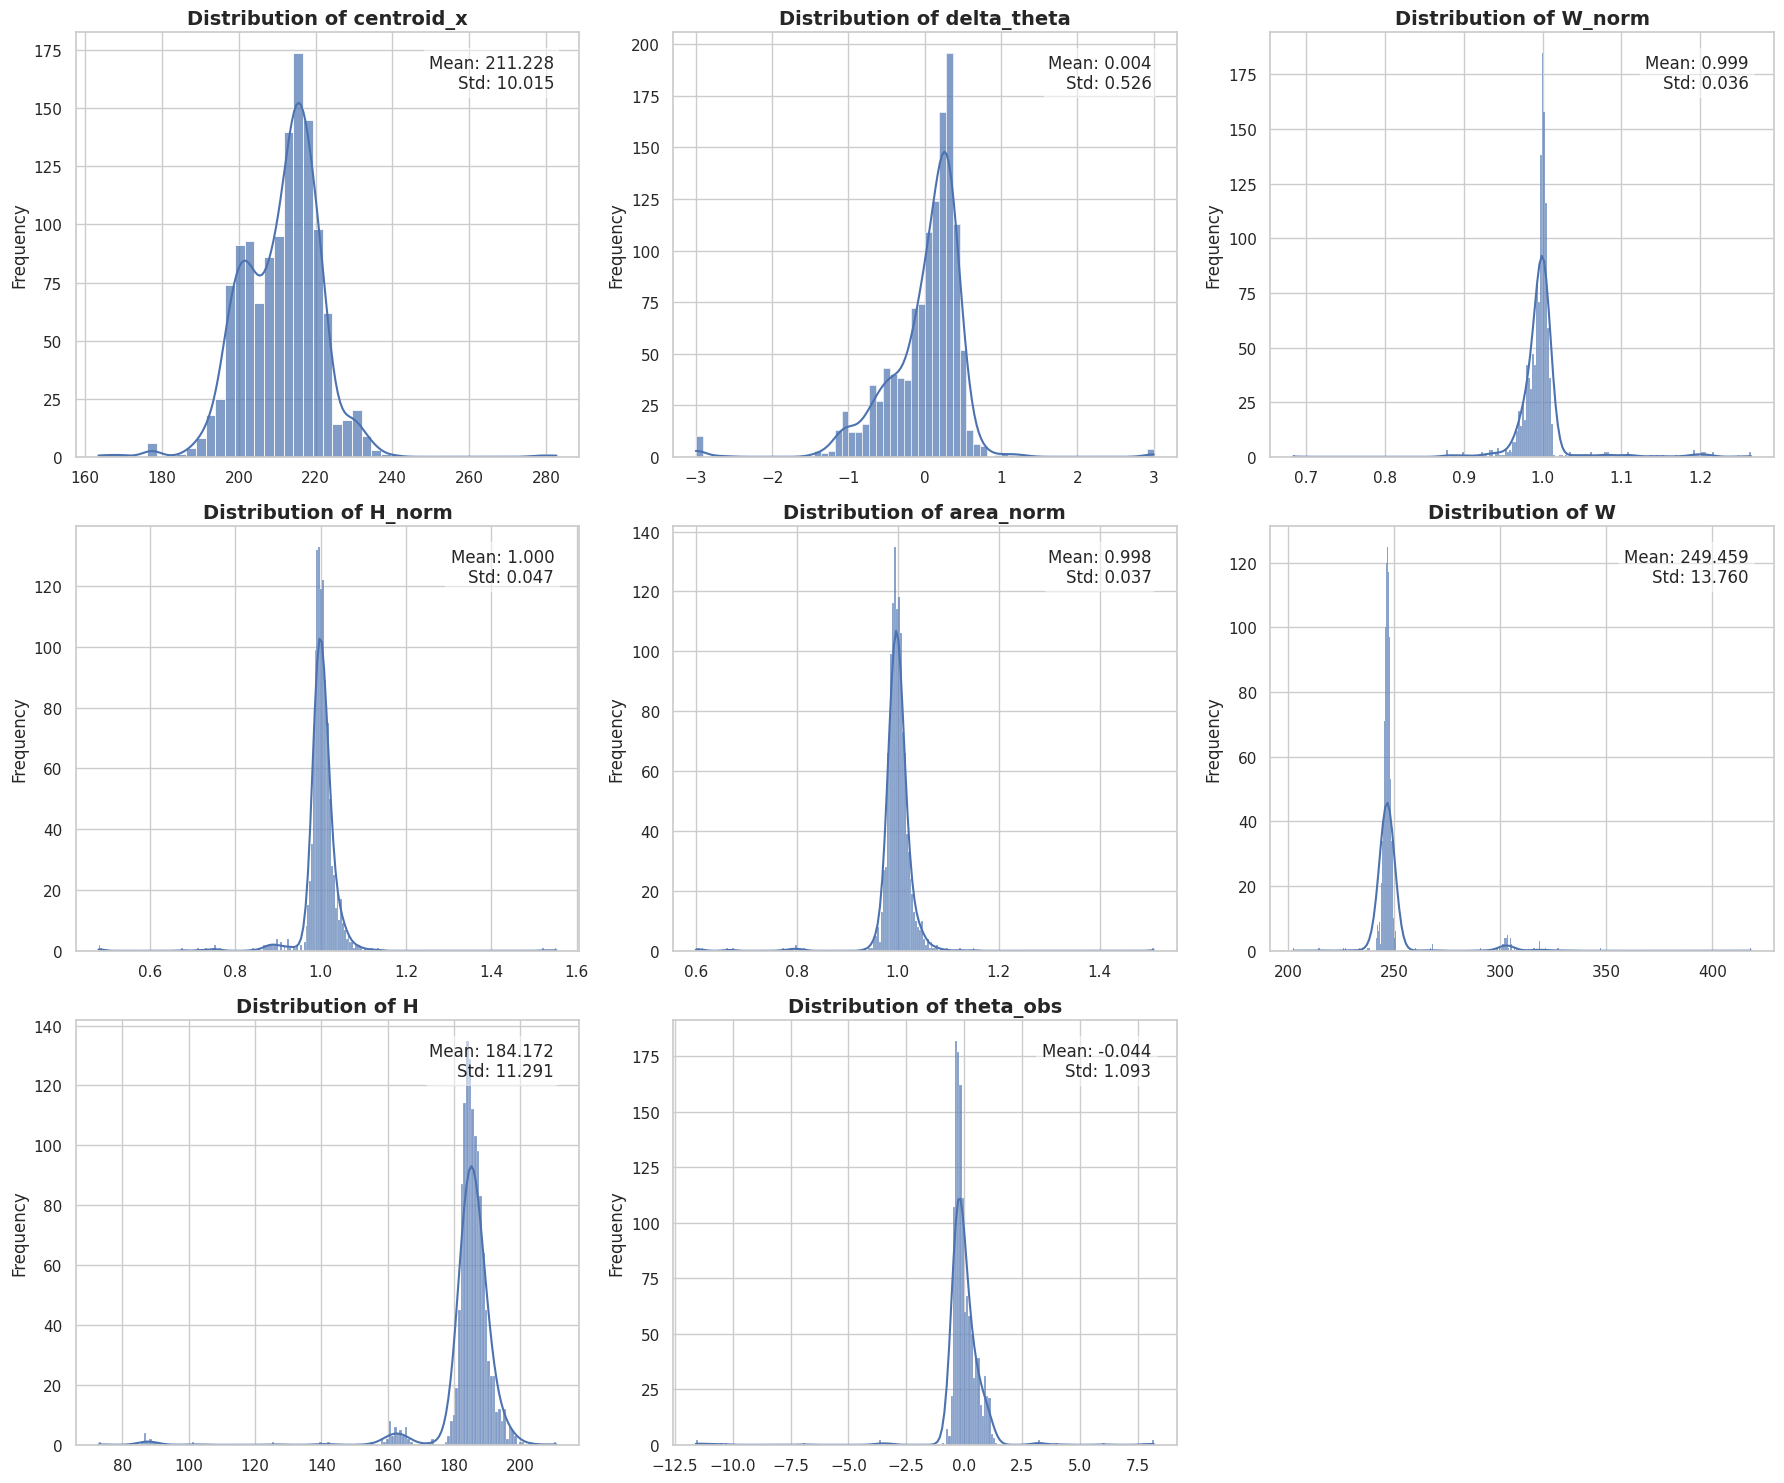

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# 0. 경로 설정 (파일 위치만 맞춰주세요)
# =========================================================
CSV_PATH = Path("/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/2. front_affine/이름변경 후_to 0412/normalized_table.csv")

# =========================================================
# 1. 데이터 로드 및 전처리
# =========================================================
df = pd.read_csv(CSV_PATH)

# 시각화할 수치형 컬럼 선정 (이미지 이름 제외)
# 예시 그래프처럼 분포를 보고 싶은 주요 지표들
cols_to_plot = [
    'centroid_x', 'delta_theta', 'W_norm',
    'H_norm', 'area_norm', 'W', 'H', 'theta_obs'
]
# 실제 데이터에 존재하는 컬럼만 필터링
cols_to_plot = [c for c in cols_to_plot if c in df.columns]

# =========================================================
# 2. 시각화 실행 (3x3 Subplot)
# =========================================================
sns.set_theme(style="whitegrid") # 배경 격자 스타일
plt.rcParams['font.family'] = 'sans-serif' # 한글 깨짐 방지가 필요하면 나눔고딕 등 설정

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten() # 2차원 배열을 1차원으로 펼쳐서 다루기 쉽게 함

for i, col in enumerate(cols_to_plot):
    # 히스토그램과 밀도 곡선 그리기 (색상은 예시와 유사한 파란색 계열)
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0', edgecolor='w', alpha=0.7)

    # 평균 및 표준편차 계산
    m = df[col].mean()
    s = df[col].std()

    # 그래프 타이틀 및 통계 정보 추가
    axes[i].set_title(f"Distribution of {col}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequency")

    # 텍스트 박스로 통계치 표시 (그래프 우측 상단)
    axes[i].text(0.95, 0.95, f"Mean: {m:.3f}\nStd: {s:.3f}",
                 transform=axes[i].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# 사용하지 않는 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# =========================================================
# 3. 결과 출력
# =========================================================
print("시각화 완료!")
plt.show()
